# Significant Wave Height Forecasting at Cape Hatteras

A deep learning model that forecasts **significant wave height (SWH)** over the
ocean off North Carolina, reproducing and extending **Ma, Ding, Ai, Liu & Bu
(2025)**, *Ocean Engineering* 340:122269.

---

### What is significant wave height?

SWH is **not** the height of one wave. It is the average height of the highest
one third of the waves in a record, usually measured over 20-30 minutes. It
describes the *sea state* -- how rough the ocean is -- and it changes over
hours as weather systems move, not over seconds.

That is why forecasting it an hour ahead makes sense: the quantity itself is
only defined over a half-hour window.

### What the model does

```
  input:   48 hours of past maps,  shape (8, 48, 32, 48)
             |    |   |   |
             |    |   |   +-- 48 longitude points  (83.5 W .. 60.0 W)
             |    |   +------ 32 latitude points   (28.5 N .. 44.0 N)
             |    +---------- 48 past hours
             +--------------- 8 channels = 7 physical fields + 1 land mask
             |
             v
         3D U-Net  (a neural network)
             |
             v
  output:  one map of SWH, h hours into the future,  shape (1, 32, 48)
```

The grid spacing is 0.5 degrees, which is the native resolution of ERA5's wave
model, so each cell is roughly **56 km north-south by 46 km east-west**. The
box was chosen so that 32 and 48 are both divisible by 8 — the U-Net halves the
grid three times (32→16→8→4, 48→24→12→6) and any other size would need padding.

Run this notebook with the **Python (oceanwave)** kernel. Every figure is
generated by the code in the cell above it, so you can change a plot and re-run
just that cell.

In [1]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))

import config
from config import FIGURES, GRID_RES, LAT_MIN, LON_MIN, N_LAT, N_LON, OUTPUTS, TABLES

pd.set_option("display.width", 160)
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")
plt.rcParams.update({"figure.dpi": 110, "axes.grid": False,
                     "font.size": 10, "axes.titlesize": 11})

BLUE, RED, GREY = "#1f6fb4", "#d73027", "#888888"

print(f"domain      : {config.LAT_MIN}-{config.LAT_MAX} N, "
      f"{abs(config.LON_MAX)}-{abs(config.LON_MIN)} W")
print(f"grid        : {config.N_LAT} x {config.N_LON} points at "
      f"{config.GRID_RES} deg (~55 km per cell)")
print(f"period      : {config.YEAR_START}-{config.YEAR_END}, hourly")
print(f"test years  : {config.TEST_YEARS}  (never seen during training)")

domain      : 28.5-44.0 N, 60.0-83.5 W
grid        : 32 x 48 points at 0.5 deg (~55 km per cell)
period      : 2000-2025, hourly
test years  : (2021, 2022, 2023, 2024, 2025)  (never seen during training)


## 1. The data

**ERA5** is a reanalysis: a physics-based ocean wave model run by ECMWF,
corrected using satellite measurements. It is the closest thing to a complete
hourly map of the ocean's wave field, and it is what the model learns from.

Every hour we have seven physical maps over the same grid:

| # | channel | what it is | unit |
|---|---|---|---|
| 0 | `swh` | significant wave height — **what we predict** | m |
| 1 | `mp2` | mean zero-crossing wave period | s |
| 2 | `pp1d` | peak wave period | s |
| 3 | `mwd_sin` | sine of mean wave direction | — |
| 4 | `mwd_cos` | cosine of mean wave direction | — |
| 5 | `u10` | east-west wind at 10 m above the sea | m/s |
| 6 | `v10` | north-south wind at 10 m above the sea | m/s |

Two things worth noticing:

**Wave direction takes two channels.** It is one physical quantity (an angle
from 0 to 360°), but 359° and 1° are next to each other in reality while being
far apart as numbers. Splitting it into a sine and a cosine removes that jump.

**An eighth channel is added later.** `dataset.py` appends a land mask (1 over
ocean, 0 over land) so the network knows which cells are not water — 27.8% of
this box is land. That is why the input tensor has 8 channels, not 7.

In [2]:
meta = json.loads((ROOT / "data/processed/era5_hatteras_meta.json").read_text())
stats = json.loads((ROOT / "data/processed/norm_stats.json").read_text())

print(f"total hourly time steps : {meta['shape'][0]:,}")
print(f"land fraction of grid   : {meta['land_fraction']:.1%}")
print(f"gaps in the record      : {meta['n_time_gaps']}\n")

summary = pd.DataFrame(stats).T[["min", "max", "mean", "std"]]
summary.index.name = "channel"
display(summary.style.format("{:.2f}").set_caption(
    "Range of each channel over the training years"))

total hourly time steps : 227,928
land fraction of grid   : 27.8%
gaps in the record      : 0



,min,max,mean,std
channel,,,,
swh,0.03,15.89,1.88,1.11
mp2,1.38,12.31,5.23,1.25
pp1d,1.83,21.24,8.20,2.24
mwd_sin,-1.00,1.00,0.10,0.72
mwd_cos,-1.00,1.00,-0.07,0.68
u10,-34.68,36.01,1.54,5.58
v10,-35.30,36.45,0.43,5.66


## 2. The question every forecast must answer first

Wave height changes slowly. So before believing any model, ask what happens if
you simply assume **nothing changes** -- that the SWH one hour from now equals
the SWH right now.

That is the **persistence** forecast. It has no parameters and takes no
training. Any model that cannot beat it is not doing anything useful.

In [3]:
base = pd.read_csv(TABLES / "baseline_swh.csv")
sel = (base["split"] == "test") & (base["stratum"] == "all")
persist = base[sel & (base["model"] == "persistence")]
clim = base[sel & (base["model"] == "climatology") & (base["lead"] == 1)]

t = persist.set_index("lead")[["mae", "rmse"]]
t.columns = ["MAE (m)", "RMSE (m)"]
display(t.style.format("{:.3f}").set_caption(
    "Doing nothing: persistence error, test years 2021-2025"))
print(f"climatology (always predict the long-term average): "
      f"MAE {clim['mae'].iloc[0]:.3f} m")

,MAE (m),RMSE (m)
lead,,
1,0.043,0.076
3,0.122,0.210
6,0.224,0.379
12,0.385,0.632
24,0.589,0.928
48,0.742,1.125


climatology (always predict the long-term average): MAE 0.729 m


Two things to notice:

* At **+1 h** persistence is already very accurate (0.043 m). There is not much
  room left for a model to improve on it.
* By **+48 h** persistence (0.741 m) is no better than predicting the long-term
  average (0.716 m). The information in "what it is doing now" has run out.

So the interesting range is in between. The source paper only ever forecasts
+1 h, and never compares against persistence at all.

## 3. How well does the model do?

Four models trained on identical data with identical settings, so the
comparison is between architectures rather than tuning effort.

In [4]:
LABELS = {
    "unet3d_swh_full_lb48_h1": "3D U-Net",
    "convlstm_swh_full_lb48_h1": "ConvLSTM",
    "cnn3d_swh_full_lb48_h1": "3D CNN",
    "unet3d_swh_paper_swh_lb48_h1": "3D U-Net (paper's inputs)",
    "persistence": "persistence",
    "climatology": "climatology",
}

m1 = pd.read_csv(TABLES / "test_metrics_swh_h1.csv")
m1["model"] = m1["model"].map(LABELS).fillna(m1["model"])
skill_col = next(c for c in m1.columns if c.startswith("skill_vs_"))

overall = (m1[m1["stratum"] == "all"].sort_values("mae")
           [["model", "mae", "rmse", "bias", "r2", skill_col]]
           .reset_index(drop=True))
overall.columns = ["model", "MAE (m)", "RMSE (m)", "bias (m)", "R2",
                   "skill vs persistence"]
display(overall.style.format({
    "MAE (m)": "{:.3f}", "RMSE (m)": "{:.3f}", "bias (m)": "{:+.3f}",
    "R2": "{:.4f}", "skill vs persistence": "{:+.3f}"}, na_rep="reference")
    .set_caption("SWH forecast at +1 h, test years 2021-2025"))

a = overall.loc[overall["model"] == "3D U-Net", "MAE (m)"].iloc[0]
b = overall.loc[overall["model"] == "3D U-Net (paper's inputs)", "MAE (m)"].iloc[0]
print(f"\nSame network, only the input channels differ:")
print(f"  all seven channels        : {a:.3f} m")
print(f"  paper's channels (no SWH) : {b:.3f} m   ({(b - a) / a:+.0%})")

,model,MAE (m),RMSE (m),bias (m),R2,skill vs persistence
0,3D U-Net,0.021,0.038,+0.003,0.9988,+0.758
1,ConvLSTM,0.024,0.038,-0.001,0.9988,+0.752
2,3D CNN,0.030,0.049,+0.000,0.9980,+0.589
3,3D U-Net (paper's inputs),0.039,0.057,+0.009,0.9972,+0.442
4,persistence,0.043,0.077,-0.001,0.9951,reference
5,climatology,0.716,0.992,-0.000,0.1754,-165.875



Same network, only the input channels differ:
  all seven channels        : 0.021 m
  paper's channels (no SWH) : 0.039 m   (+83%)


**Skill** is `1 - MSE(model) / MSE(persistence)`. Zero means no better than
doing nothing; one would be a perfect forecast.

The last row is the same 3D U-Net trained on the paper's own choice of inputs,
which **omits SWH itself** -- the network never sees the history of the
quantity it is predicting. That single change nearly doubles the error, and it
matters more than which architecture you pick.

## 4. Loading the forecasts

Everything below plots the actual forecast fields. They were produced once and
cached; if the cache is missing this cell regenerates it, which needs the GPU
and takes a few minutes.

In [5]:
PRED_CACHE = OUTPUTS / "predictions_h1.npz"
LEAD = 1
CHECKPOINT = "unet3d_swh_full_lb48_h1"

def build_predictions(lead, checkpoint, stride=12):
    "Run the trained model over the test years and cache the fields."
    import torch
    from torch.utils.data import DataLoader
    from dataset import ERA5Cache, WaveWindowDataset
    from models import build
    from train import CHECKPOINTS

    device = "cuda" if torch.cuda.is_available() else "cpu"
    ckpt = torch.load(CHECKPOINTS / f"{checkpoint}.pt", map_location=device,
                      weights_only=False)
    a = ckpt["args"]
    cache = ERA5Cache()
    ds = WaveWindowDataset(cache=cache, split="test", target=a["target"],
                           channel_set=a["channel_set"], lookback=a["lookback"],
                           lead=a["lead"], stride=stride)
    loader = DataLoader(ds, batch_size=32, num_workers=4, shuffle=False)
    model = build(a["model"], in_channels=ds.n_channels, lookback=a["lookback"],
                  base_channels=a["base_channels"], depth=a["depth"]).to(device)
    model.load_state_dict(ckpt["model"]); model.eval()

    s = cache.stats[a["target"]]
    scale, offset = s["max"] - s["min"], s["min"]
    P, T, Q, V, I = [], [], [], [], []
    with torch.no_grad():
        for b in loader:
            x = b["x"].to(device); ocean = b["valid"].to(device).float()
            with torch.autocast("cuda", dtype=torch.bfloat16,
                                enabled=(device == "cuda")):
                out = model(x, ocean)
            P.append((out.float() * scale + offset).cpu().numpy()[:, 0].astype("float32"))
            T.append(b["y_phys"].numpy()[:, 0]); Q.append(b["persist"].numpy()[:, 0])
            V.append(b["valid"].numpy()[:, 0]); I.append(b["t_index"].numpy())
    idx = np.concatenate(I)
    d = dict(pred=np.concatenate(P), true=np.concatenate(T),
             persist=np.concatenate(Q), valid=np.concatenate(V),
             t_index=idx, times=cache.times[idx + lead], ocean=cache.ocean)
    np.savez_compressed(PRED_CACHE, **d)
    return d

if PRED_CACHE.exists():
    _d = np.load(PRED_CACHE, allow_pickle=True)
    D = {k: _d[k] for k in _d.files}
    print(f"loaded cached forecasts: {PRED_CACHE.name}")
else:
    D = build_predictions(LEAD, CHECKPOINT)
    print("computed and cached forecasts")

MASK = D["valid"].astype(bool)
PRED, TRUE, PERS = D["pred"][MASK], D["true"][MASK], D["persist"][MASK]

def scores(p, t):
    e = p - t
    return dict(n=len(t), mae=np.mean(np.abs(e)), rmse=np.sqrt(np.mean(e**2)),
                bias=np.mean(e), corr=np.corrcoef(p, t)[0, 1],
                si=np.std(e) / t.mean())

s = scores(PRED, TRUE)
print(f"\n{D['pred'].shape[0]:,} forecast maps, {s['n']:,} ocean points")
print(f"RMSE {s['rmse']:.3f} m   MAE {s['mae']:.3f} m   "
      f"R {s['corr']:.4f}   bias {s['bias']:+.3f} m   SI {s['si']:.3f}")

loaded cached forecasts: predictions_h1.npz

3,648 forecast maps, 4,044,413 ocean points
RMSE 0.043 m   MAE 0.023 m   R 0.9993   bias +0.003 m   SI 0.024


### 4.1 Forecast against reference

The classic wave-model plot. Every point is one grid cell at one hour; colour
is how many points fall in that hexagon. A perfect forecast lies exactly on the
dashed 1:1 line. `SI` is the scatter index, the error standard deviation
divided by the mean wave height.

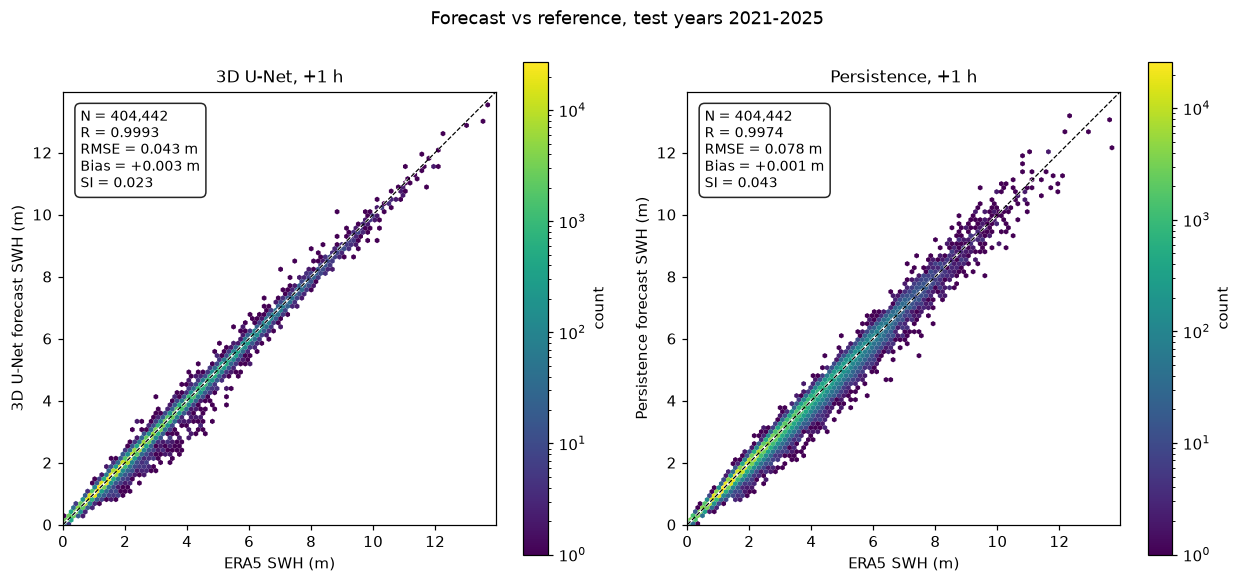

In [6]:
step = max(1, len(TRUE) // 400_000)
t_s, p_s, q_s = TRUE[::step], PRED[::step], PERS[::step]

fig, axes = plt.subplots(1, 2, figsize=(11.5, 5.2))
for ax, (yy, name) in zip(axes, [(p_s, "3D U-Net"), (q_s, "Persistence")]):
    hb = ax.hexbin(t_s, yy, gridsize=90, bins="log", mincnt=1,
                   cmap="viridis", linewidths=0)
    top = max(t_s.max(), yy.max()) * 1.02
    ax.plot([0, top], [0, top], "w--", lw=1.6)
    ax.plot([0, top], [0, top], "k--", lw=0.8)
    sc = scores(yy, t_s)
    ax.text(0.04, 0.96, f"N = {sc['n']:,}\nR = {sc['corr']:.4f}\n"
            f"RMSE = {sc['rmse']:.3f} m\nBias = {sc['bias']:+.3f} m\n"
            f"SI = {sc['si']:.3f}", transform=ax.transAxes, va="top",
            fontsize=9, bbox=dict(boxstyle="round,pad=0.4", fc="white", alpha=.85))
    ax.set_xlim(0, top); ax.set_ylim(0, top); ax.set_aspect("equal")
    ax.set_xlabel("ERA5 SWH (m)"); ax.set_ylabel(f"{name} forecast SWH (m)")
    ax.set_title(f"{name}, +{LEAD} h")
    fig.colorbar(hb, ax=ax, label="count")
fig.suptitle("Forecast vs reference, test years 2021-2025", y=1.0)
fig.tight_layout(); plt.show()

### 4.2 A time series at one location

The same forecast seen as a time series at the grid cell off Cape Hatteras,
during the roughest three weeks of the test period. The lower panel is the
error.

**Try changing** `POINT_LAT` / `POINT_LON` to somewhere else in the domain.

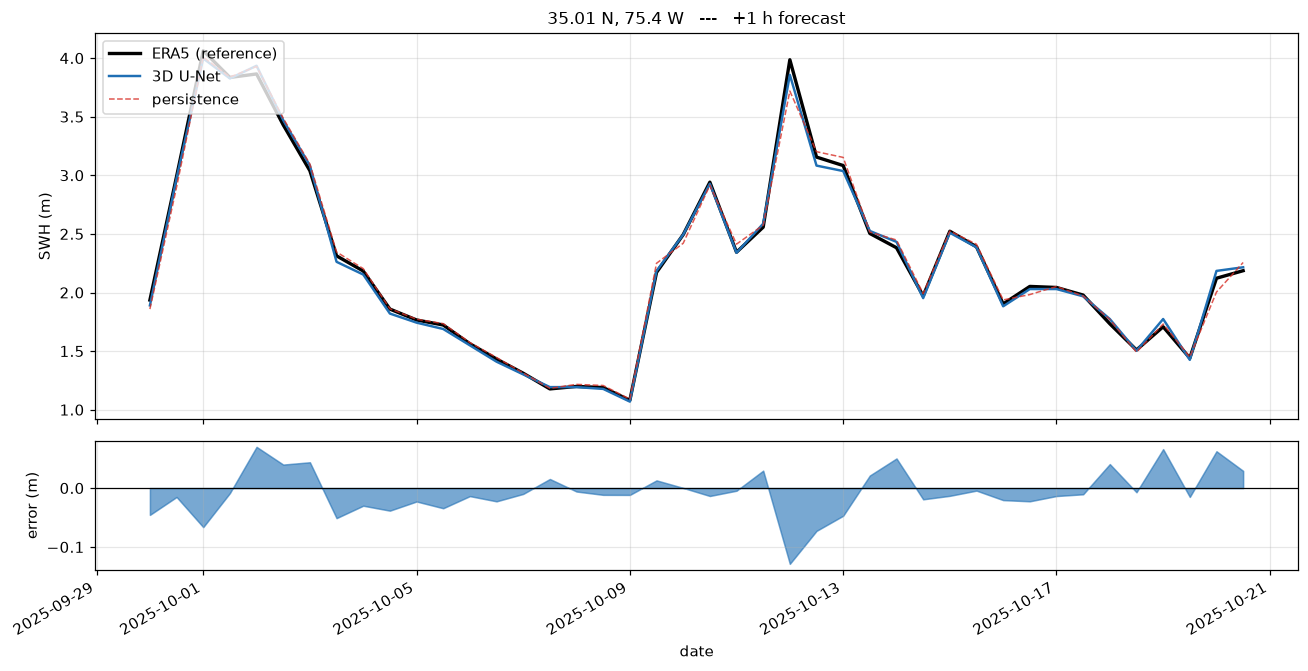

In [7]:
POINT_LAT, POINT_LON = 35.01, -75.40      # Cape Hatteras / Diamond Shoals

i = int(round((POINT_LAT - LAT_MIN) / GRID_RES))
j = int(round((POINT_LON - LON_MIN) / GRID_RES))
true_p, pred_p, pers_p = D["true"][:, i, j], D["pred"][:, i, j], D["persist"][:, i, j]
times = D["times"].astype("datetime64[h]")

step_h = max(1, int(np.median(np.diff(D["t_index"]))))
span = max(8, (21 * 24) // step_h)
roll = np.convolve(true_p, np.ones(span) / span, mode="valid")
sl = slice(int(np.argmax(roll)), int(np.argmax(roll)) + span)

fig, ax = plt.subplots(2, 1, figsize=(12, 6.2), sharex=True,
                       gridspec_kw={"height_ratios": [3, 1]})
ax[0].plot(times[sl], true_p[sl], "k", lw=2.2, label="ERA5 (reference)")
ax[0].plot(times[sl], pred_p[sl], color=BLUE, lw=1.6, label="3D U-Net")
ax[0].plot(times[sl], pers_p[sl], color=RED, lw=1.0, ls="--", alpha=.8,
           label="persistence")
ax[0].set_ylabel("SWH (m)"); ax[0].legend(loc="upper left"); ax[0].grid(alpha=.3)
ax[0].set_title(f"{POINT_LAT} N, {abs(POINT_LON)} W   ---   +{LEAD} h forecast")
ax[1].axhline(0, color="k", lw=.8)
ax[1].fill_between(times[sl], 0, pred_p[sl] - true_p[sl], color=BLUE, alpha=.6)
ax[1].set_ylabel("error (m)"); ax[1].set_xlabel("date"); ax[1].grid(alpha=.3)
fig.autofmt_xdate(); fig.tight_layout(); plt.show()

### 4.3 Maps of the whole domain

The reference field, the forecast, and their difference, at the single
highest-wave hour in the test years. The star marks Cape Hatteras.

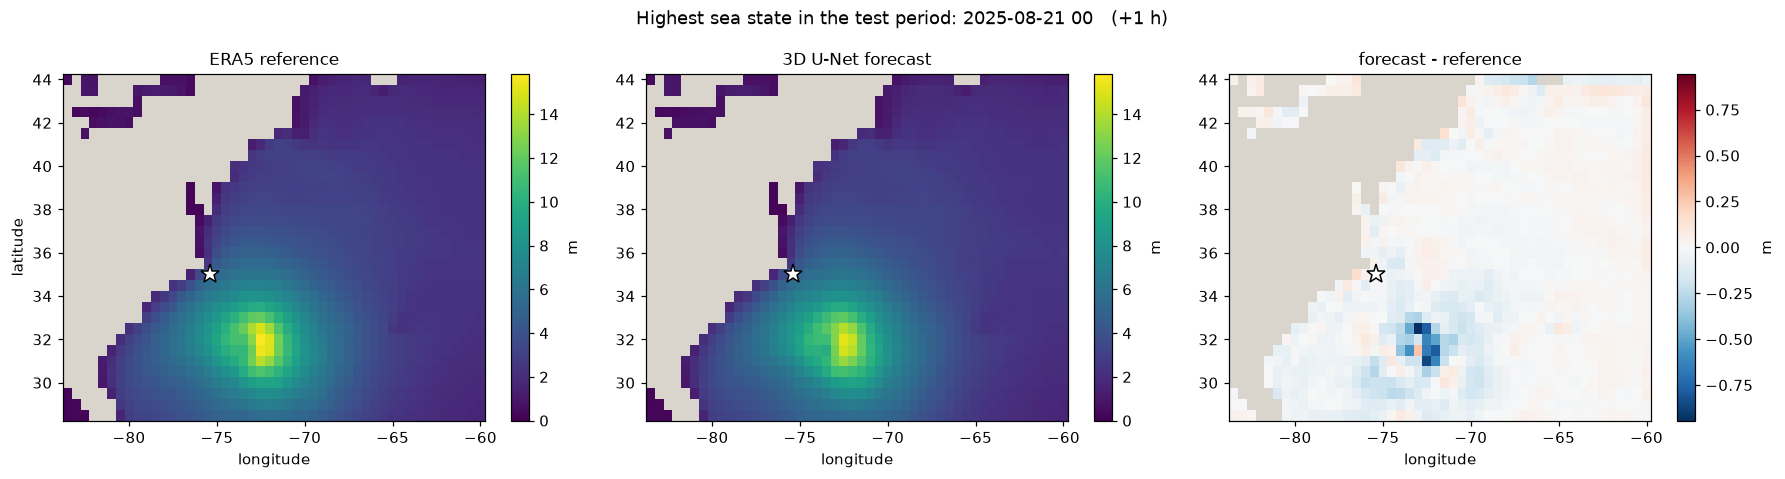

In [8]:
ocean = D["ocean"].astype(bool)
k = int(np.nanargmax(np.nanmax(np.where(MASK, D["true"], np.nan), axis=(1, 2))))
when = str(D["times"][k])[:16].replace("T", " ")

true_f = np.where(ocean, D["true"][k], np.nan)
pred_f = np.where(ocean, D["pred"][k], np.nan)
err_f = pred_f - true_f
lats = LAT_MIN + np.arange(N_LAT) * GRID_RES
lons = LON_MIN + np.arange(N_LON) * GRID_RES
vmax, elim = np.nanmax(true_f), np.nanmax(np.abs(err_f))

fig, axes = plt.subplots(1, 3, figsize=(16.5, 4.4))
panels = [(true_f, "ERA5 reference", "viridis", dict(vmin=0, vmax=vmax)),
          (pred_f, "3D U-Net forecast", "viridis", dict(vmin=0, vmax=vmax)),
          (err_f, "forecast - reference", "RdBu_r", dict(vmin=-elim, vmax=elim))]
for ax, (field, title, cmap, kw) in zip(axes, panels):
    m = ax.pcolormesh(lons, lats, field, cmap=cmap, shading="auto", **kw)
    ax.set_facecolor("#d9d4cc"); ax.set_title(title); ax.set_xlabel("longitude")
    ax.plot(POINT_LON, POINT_LAT, "*", ms=13, color="w", mec="k", mew=1.0)
    fig.colorbar(m, ax=ax, label="m")
axes[0].set_ylabel("latitude")
fig.suptitle(f"Highest sea state in the test period: {when}   (+{LEAD} h)")
fig.tight_layout(); plt.show()

### 4.4 Taylor diagram

A compact way to compare models at once. The angle is correlation with the
reference, the radius is variability relative to the reference, and distance
from the black star is the centred error. A perfect model sits on the star.

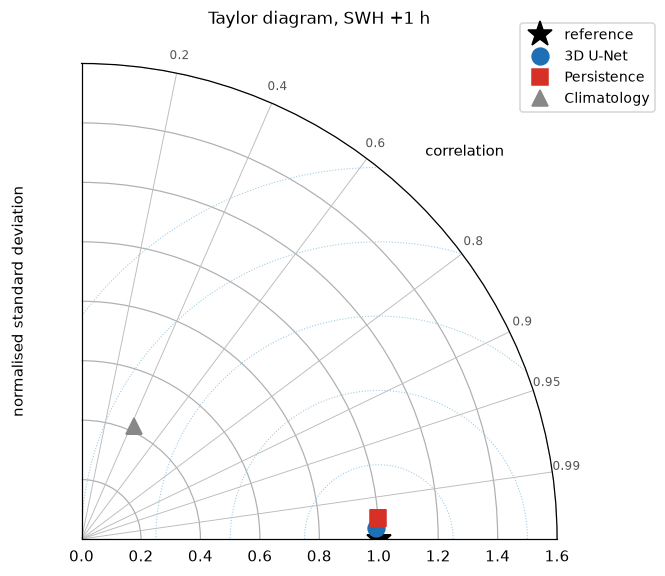

In [9]:
counts = MASK.sum(axis=0, keepdims=True)
sums = np.where(MASK, D["true"], 0).sum(axis=0, keepdims=True)
clim_field = np.divide(sums, counts, out=np.zeros_like(sums), where=counts > 0)
CLIM = np.broadcast_to(clim_field, D["true"].shape)[MASK]

st = max(1, len(TRUE) // 300_000)
t_r, entries = TRUE[::st], [("3D U-Net", PRED[::st], BLUE, "o"),
                            ("Persistence", PERS[::st], RED, "s"),
                            ("Climatology", CLIM[::st], GREY, "^")]
ref_std, smax = t_r.std(), 1.6

fig = plt.figure(figsize=(6.8, 6.4))
ax = fig.add_subplot(111, polar=True)
ax.set_thetalim(0, np.pi / 2); ax.set_rlim(0, smax)
for c in (0.2, 0.4, 0.6, 0.8, 0.9, 0.95, 0.99):
    ax.plot([np.arccos(c)] * 2, [0, smax], color="#bbbbbb", lw=.6)
    ax.text(np.arccos(c), smax * 1.03, f"{c}", ha="center", fontsize=8, color="#555")
ax.text(np.pi / 4, smax * 1.14, "correlation", ha="center")
th = np.linspace(0, np.pi, 200)
for rms in (0.25, 0.5, 0.75, 1.0, 1.25):
    x, y = 1 + rms * np.cos(th), rms * np.sin(th)
    r = np.hypot(x, y); keep = r <= smax
    ax.plot(np.arctan2(y[keep], x[keep]), r[keep], color="#9ecae1", lw=.7, ls=":")
ax.plot(0, 1.0, "*", ms=17, color="k", label="reference")
for name, arr, colour, mk in entries:
    ax.plot(np.arccos(np.corrcoef(arr, t_r)[0, 1]), arr.std() / ref_std,
            mk, ms=11, color=colour, ls="none", label=name)
ax.set_rlabel_position(100); ax.set_xticks([])
ax.set_ylabel("normalised standard deviation", labelpad=28)
ax.legend(loc="upper right", bbox_to_anchor=(1.22, 1.10), fontsize=9)
ax.set_title(f"Taylor diagram, SWH +{LEAD} h", pad=26)
fig.tight_layout(); plt.show()

### 4.5 Distributions and error behaviour

* **Left** -- a Q-Q plot. Does the forecast reproduce the *distribution* of
  wave heights, not just the average? A model can have a good RMSE while
  quietly compressing the range.
* **Middle** -- the error distribution, log scale so rare large errors show.
* **Right** -- error as a function of how rough the sea is. Errors grow with
  wave height for every method; the question is how fast.

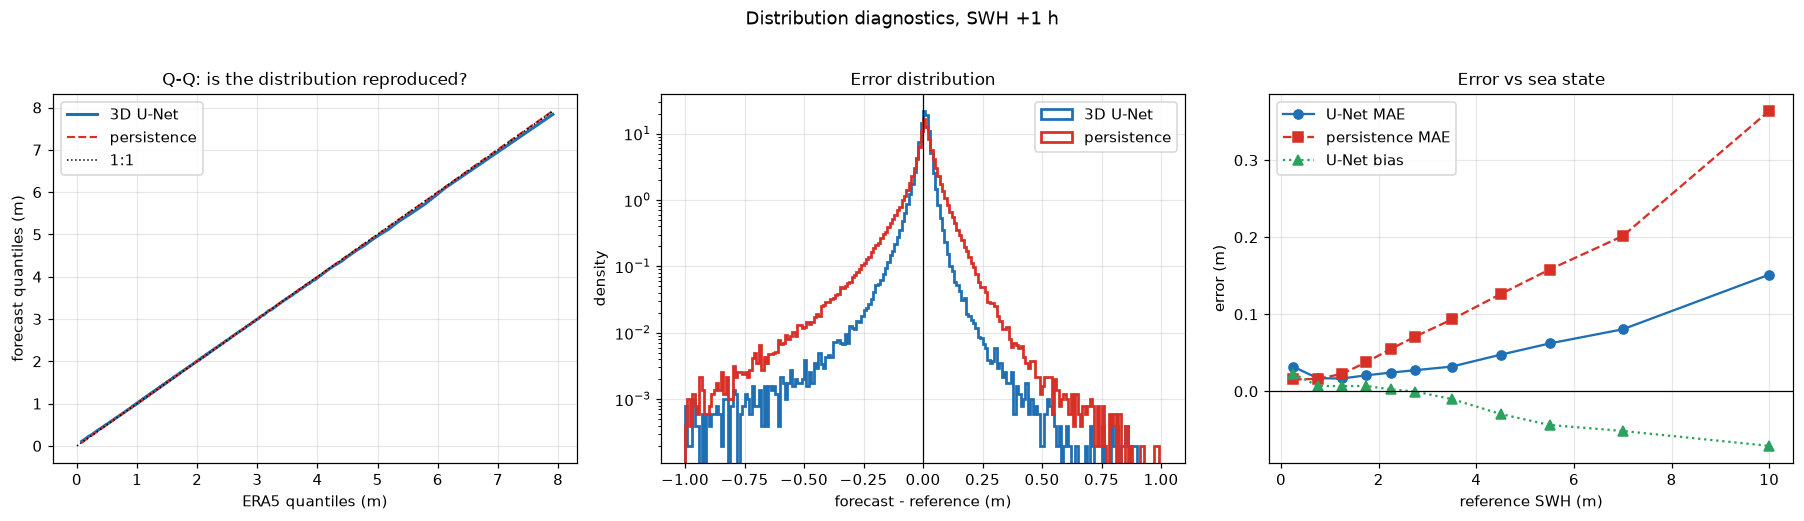

In [10]:
st = max(1, len(TRUE) // 500_000)
p_, t_, q_ = PRED[::st], TRUE[::st], PERS[::st]

fig, axes = plt.subplots(1, 3, figsize=(16.5, 4.6))

qs = np.linspace(0.1, 99.9, 400)
tq = np.percentile(t_, qs)
axes[0].plot(tq, np.percentile(p_, qs), color=BLUE, lw=2, label="3D U-Net")
axes[0].plot(tq, np.percentile(q_, qs), color=RED, lw=1.4, ls="--",
             label="persistence")
axes[0].plot([0, tq.max()], [0, tq.max()], "k:", lw=1, label="1:1")
axes[0].set_xlabel("ERA5 quantiles (m)"); axes[0].set_ylabel("forecast quantiles (m)")
axes[0].set_title("Q-Q: is the distribution reproduced?")
axes[0].legend(); axes[0].grid(alpha=.3)

for arr, colour, name in ((p_, BLUE, "3D U-Net"), (q_, RED, "persistence")):
    axes[1].hist(arr - t_, bins=200, range=(-1, 1), histtype="step", lw=1.8,
                 color=colour, density=True, label=name)
axes[1].axvline(0, color="k", lw=.8); axes[1].set_yscale("log")
axes[1].set_xlabel("forecast - reference (m)"); axes[1].set_ylabel("density")
axes[1].set_title("Error distribution"); axes[1].legend(); axes[1].grid(alpha=.3)

edges = np.array([0, .5, 1, 1.5, 2, 2.5, 3, 4, 5, 6, 8, 12])
ctr, mu, mp, bu = [], [], [], []
for lo, hi in zip(edges[:-1], edges[1:]):
    sel = (t_ >= lo) & (t_ < hi)
    if sel.sum() < 50:
        continue
    ctr.append((lo + hi) / 2)
    mu.append(np.mean(np.abs(p_[sel] - t_[sel])))
    mp.append(np.mean(np.abs(q_[sel] - t_[sel])))
    bu.append(np.mean(p_[sel] - t_[sel]))
axes[2].plot(ctr, mu, "o-", color=BLUE, label="U-Net MAE")
axes[2].plot(ctr, mp, "s--", color=RED, label="persistence MAE")
axes[2].plot(ctr, bu, "^:", color="#2ca25f", label="U-Net bias")
axes[2].axhline(0, color="k", lw=.8)
axes[2].set_xlabel("reference SWH (m)"); axes[2].set_ylabel("error (m)")
axes[2].set_title("Error vs sea state"); axes[2].legend(); axes[2].grid(alpha=.3)

fig.suptitle(f"Distribution diagnostics, SWH +{LEAD} h", y=1.02)
fig.tight_layout(); plt.show()

### 4.6 Training curves

How the models learned. Thin lines are training loss, thick lines validation
loss. The right panel shows validation skill against persistence -- the moment
a curve crosses zero is the moment that model became worth using.

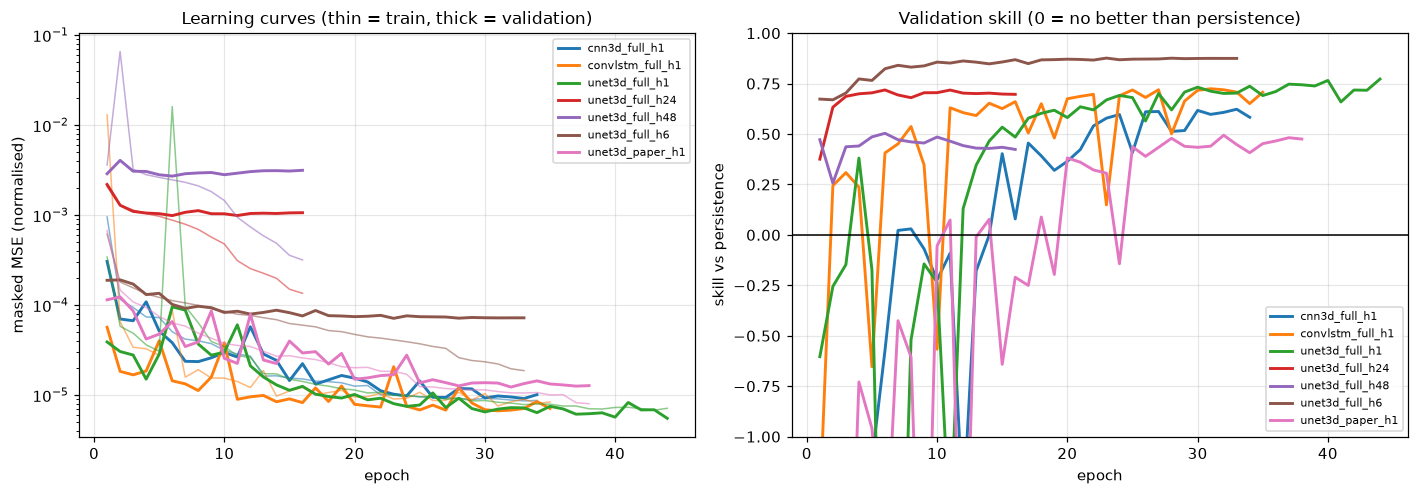

In [11]:
from train import LOGS

runs = [p for p in sorted(LOGS.glob("*.json")) if "smoke" not in p.name]
fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))
cmap = plt.get_cmap("tab10")
for k, path in enumerate(runs):
    h = json.loads(path.read_text())
    ep = [r["epoch"] for r in h]
    label = path.stem.replace("_swh", "").replace("_lb48", "")
    axes[0].plot(ep, [r["train_loss"] for r in h], color=cmap(k), lw=1, alpha=.55)
    axes[0].plot(ep, [r["val_loss"] for r in h], color=cmap(k), lw=1.9, label=label)
    axes[1].plot(ep, [r["skill_vs_persistence"] for r in h], color=cmap(k),
                 lw=1.9, label=label)
axes[0].set_yscale("log"); axes[0].set_xlabel("epoch")
axes[0].set_ylabel("masked MSE (normalised)")
axes[0].set_title("Learning curves (thin = train, thick = validation)")
axes[0].grid(alpha=.3); axes[0].legend(fontsize=7)
axes[1].axhline(0, color="k", lw=1); axes[1].set_ylim(-1, 1)
axes[1].set_xlabel("epoch"); axes[1].set_ylabel("skill vs persistence")
axes[1].set_title("Validation skill (0 = no better than persistence)")
axes[1].grid(alpha=.3); axes[1].legend(fontsize=7)
fig.tight_layout(); plt.show()

## 5. Forecasting further ahead

The same architecture trained separately for +1, +6, +24 and +48 hour lead
times.

,lead,U-Net MAE (m),persistence MAE (m),skill,U-Net R2
0,+1 h,0.021,0.043,+0.758,0.999
1,+6 h,0.082,0.223,+0.879,0.985
2,+24 h,0.332,0.588,+0.693,0.779
3,+48 h,0.541,0.741,+0.485,0.455


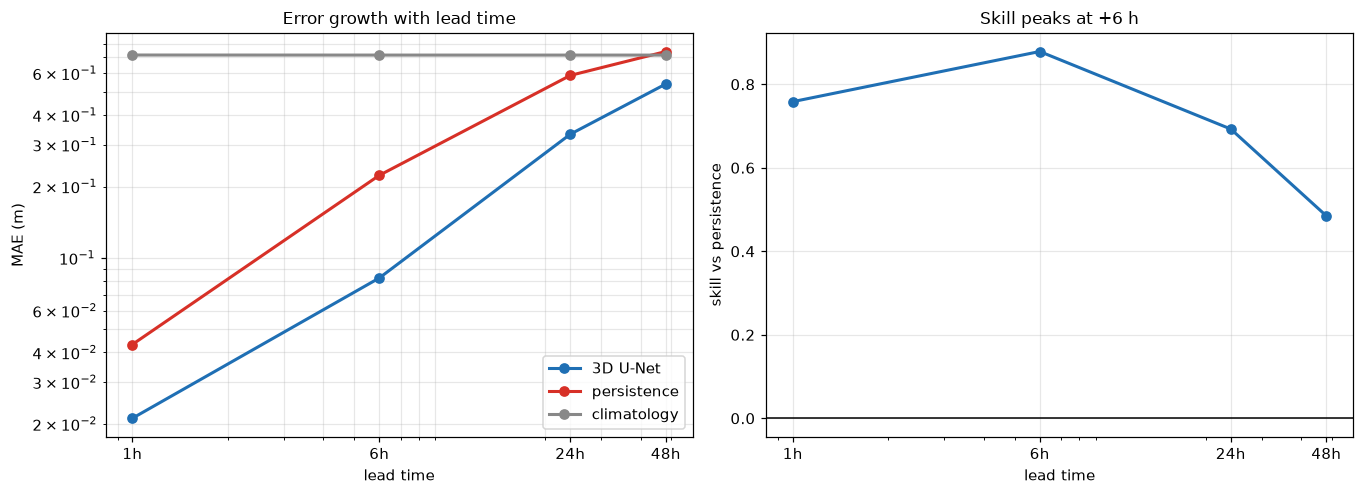

In [12]:
LEADS = (1, 6, 24, 48)
frames = []
for L in LEADS:
    df = pd.read_csv(TABLES / f"test_metrics_swh_h{L}.csv"); df["lead"] = L
    frames.append(df)
allm = pd.concat(frames, ignore_index=True)
sc_col = next(c for c in allm.columns if c.startswith("skill_vs_"))
is_all = allm["stratum"] == "all"
unet = allm[is_all & allm["model"].str.startswith("unet3d_swh_full")]
pers_l = allm[is_all & (allm["model"] == "persistence")]
clim_l = allm[is_all & (allm["model"] == "climatology")]

tbl = pd.DataFrame([{
    "lead": f"+{L} h",
    "U-Net MAE (m)": unet[unet.lead == L]["mae"].iloc[0],
    "persistence MAE (m)": pers_l[pers_l.lead == L]["mae"].iloc[0],
    "skill": unet[unet.lead == L][sc_col].iloc[0],
    "U-Net R2": unet[unet.lead == L]["r2"].iloc[0]} for L in LEADS])
display(tbl.style.format({"U-Net MAE (m)": "{:.3f}",
                          "persistence MAE (m)": "{:.3f}",
                          "skill": "{:+.3f}", "U-Net R2": "{:.3f}"})
        .set_caption("3D U-Net across lead times"))

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.6))
for name, frame, colour in (("3D U-Net", unet, BLUE),
                            ("persistence", pers_l, RED),
                            ("climatology", clim_l, GREY)):
    axes[0].plot(LEADS, [frame[frame.lead == L]["mae"].iloc[0] for L in LEADS],
                 "o-", color=colour, lw=2, label=name)
axes[0].set_xscale("log"); axes[0].set_yscale("log")
axes[0].set_xticks(LEADS); axes[0].set_xticklabels([f"{L}h" for L in LEADS])
axes[0].set_xlabel("lead time"); axes[0].set_ylabel("MAE (m)")
axes[0].set_title("Error growth with lead time")
axes[0].grid(alpha=.3, which="both"); axes[0].legend()

axes[1].plot(LEADS, [unet[unet.lead == L][sc_col].iloc[0] for L in LEADS],
             "o-", color=BLUE, lw=2)
axes[1].axhline(0, color="k", lw=1)
axes[1].set_xscale("log"); axes[1].set_xticks(LEADS)
axes[1].set_xticklabels([f"{L}h" for L in LEADS])
axes[1].set_xlabel("lead time"); axes[1].set_ylabel("skill vs persistence")
axes[1].set_title("Skill peaks at +6 h"); axes[1].grid(alpha=.3)
fig.tight_layout(); plt.show()

Skill **peaks at +6 h, not at +1 h**. At one hour persistence is already so
good that there is little left to win; at 48 hours the weather itself is no
longer predictable enough. The middle range is where a learned model earns its
place -- and it is the range the source paper never tested.

## 6. Summary

| | |
|---|---|
| Best +1 h forecast | 3D U-Net, **MAE 0.021 m**, R = 0.999, skill +0.76 |
| Best lead time | **+6 h**, skill +0.88 |
| Biggest single factor | including SWH in the inputs (**+83%** error without it) |
| Architecture ranking | U-Net ~ ConvLSTM > 3D CNN — skip connections matter more than convolution vs recurrence |

### Things to be careful about

1. **The reference is a model, not the ocean.** ERA5 is itself a wave model
   constrained by satellites, so these numbers say how well we reproduce ERA5,
   not how well we reproduce reality. Comparing against buoy measurements is
   the natural next step.
2. **The grid is coarse.** At 0.5° each cell is roughly 56 x 46 km, far too
   coarse for anything happening at the shoreline.
3. **Aggregate numbers hide behaviour.** An R² of 0.999 sounds conclusive, but
   most of that variance is the ordinary seasonal and spatial pattern of the
   wave field, which is easy. The plots in section 4.5 are the honest view.